# 📊 Proyecto de Análisis de Netflix

Este conjunto de datos contiene información sobre las **series y películas disponibles en Netflix**.  
Los datos provienen de **Flixable**, un motor de búsqueda de terceros, y ofrecen metadatos útiles para análisis de contenidos, sistemas de recomendación y estudios de tendencias.

---

## 📋 Columnas principales del dataset

- **Show_Id**: Identificador único de cada título (ej. s1, s2...).  
- **Category**: Película o Programa de TV.  
- **Títle**: Nombre de la película o serie.  
- **Director**: Nombre(s) del director (puede estar vacío).  
- **Cast**: Actores y actrices principales (separados por comas).  
- **Country**: País(es) de producción o lanzamiento.  
- **Release_Date**: Fecha de disponibilidad en Netflix.  
- **Rating**: Calificación de madurez (TV-MA, PG-13, R, etc.).  
- **Duration**: Minutos (películas) o número de temporadas (series).  
- **Type**: Género o categoría (Dramas, Comedias, TV Internacional, etc.).  
- **Description**: Breve sinopsis del contenido.  

---

## 🎯 Preguntas del Proyecto

1. Para **House of Cards**, ¿cuál es el ID del programa y quién es el director?  
2. ¿En qué año se estrenaron el mayor número de series y películas? → gráfico de barras.  
3. ¿Cuántas películas y series de televisión hay en el dataset? → gráfico de barras.  
4. Mostrar todas las películas estrenadas en el año 2000.  
5. Mostrar solo los títulos de programas de TV emitidos únicamente en India.  
6. Top 10 directores con más títulos en Netflix.   
7. Audiencias definidas por Netflix:  
   - 9.1) ¿Cuántas películas tienen calificación **TV-14** en Canadá?  
   - 9.2) ¿Cuántos programas de TV tienen calificación **R** después de 2018?  
8. Mostrar distibucion de titulos por paises
9. ¿Cuál es la duración máxima de una película/serie en Netflix?  

---

## 💡 Uso del dataset en Python




In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("Netflix Dataset.csv")
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


----

## **Funciones auxiliares**




### buscar_info()
Esta función permite buscar un título específico en el dataset de Netflix.  
Devuelve el **ID del programa** y el **director** si existe, o un mensaje si no se encuentra.  
Se utiliza `str.contains()` para coincidencias parciales sin importar mayúsculas/minúsculas.

In [3]:
def buscar_info(df, titulo):
    """
    Busca el ID y el director de un título específico en el dataset de Netflix.
    
    Parámetros:
    df : DataFrame de Pandas con los datos de Netflix
    titulo : str, nombre exacto o parcial del título a buscar
    
    Retorna:
    dict con show_id y director, o mensaje si no se encuentra
    """
    # Filtrar por coincidencia parcial (ignora mayúsculas/minúsculas)
    resultado = df[df["Title"].str.contains(titulo, case=False, na=False)]

    """📌 str.contains()
       Sirve para buscar coincidencias parciales dentro de una columna de texto.

       Ejemplo:
       python
       df["title"].str.contains("Cards")
       Devuelve True en las filas donde el título contiene la palabra Cards. 

       📌 case=False
          Indica que la búsqueda no distingue mayúsculas/minúsculas.
    """
    
    if resultado.empty:
        return f"No se encontró el título '{titulo}' en el dataset."
    #.empty Es una propiedad de un DataFrame que indica si está vacío (sin filas).
    
    # Tomar la primera coincidencia
    fila = resultado.iloc[0]
    return {
        "show_id": fila["Show_Id"],
        "director": fila["Director"]
    }


### peliculas_por_año()
Esta función devuelve todas las películas estrenadas en un año específico.  
- Filtra por categoría **Movie** y por columna **Year**.  
- Retorna una lista con los títulos encontrados.  
Incluye validaciones para que el año ingresado esté entre 2005 y 2026.


In [4]:
def peliculas_por_año(df, año):
    return df[(df["Category"] == "Movie") & (df["Year"] == año)]["Title"].tolist()


----

## **Limpieza de datos**
En esta sección se preparan las columnas principales del dataset:
- Conversión de fechas a tipo datetime.
- Creación de columna `Year`.
- Relleno de valores nulos en columnas textuales.
- Eliminación de duplicados.
- Conversión de la columna `Category` a tipo categórico.


In [5]:
# Convertir Release_Date a datetime
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")

# Crear columna Year
df["Year"] = df["Release_Date"].dt.year.astype("Int64")

# Rellenar valores nulos en columnas textuales
df["Director"] = df["Director"].fillna("Desconocido")
df["Country"] = df["Country"].fillna("Desconocido")
df["Cast"] = df["Cast"].fillna("Desconocido")
df["Rating"] = df["Rating"].fillna("Sin clasificación")

# Eliminar duplicados
df = df.drop_duplicates()

#Pasamos columna Category a tipo categorico 
df["Category"] = df["Category"].astype("category")


**Resultado esperado:**  
- La columna `Release_Date` ahora es de tipo datetime.  
- La columna `Year` permite agrupar y graficar por año.  
- Los valores nulos en texto se reemplazan por etiquetas descriptivas.  
- Se eliminan duplicados para evitar sesgos.  
- La columna `Category` queda optimizada como categórica (Movie / TV Show).


----
### **Observamos que tipo de dato son las columnas**



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7787 entries, 0 to 7788
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Show_Id       7787 non-null   object        
 1   Category      7787 non-null   category      
 2   Title         7787 non-null   object        
 3   Director      7787 non-null   object        
 4   Cast          7787 non-null   object        
 5   Country       7787 non-null   object        
 6   Release_Date  7689 non-null   datetime64[ns]
 7   Rating        7787 non-null   object        
 8   Duration      7787 non-null   object        
 9   Type          7787 non-null   object        
 10  Description   7787 non-null   object        
 11  Year          7689 non-null   Int64         
dtypes: Int64(1), category(1), datetime64[ns](1), object(9)
memory usage: 745.4+ KB


----
### **1. Para la pelicula House of Cards ¿Cual es el id del programa y como se llama el director?**

In [7]:
# Usamos la función auxiliar buscar_info
info_house = buscar_info(df, "House of Cards")

print("Información de House of Cards:")
print(info_house)


Información de House of Cards:
{'show_id': 's2833', 'director': 'Robin Wright, David Fincher, Gerald McRaney, John David Coles, David Manson'}


**Interpretación:**  
La función devuelve un diccionario con el **ID del programa** y el **nombre del director** de *House of Cards*.  
Esto permite localizar rápidamente información clave de un título específico dentro del catálogo de Netflix.


----
### **2.¿En qué año se estrenaron el mayor número de series y películas? → gráfico de barras**  

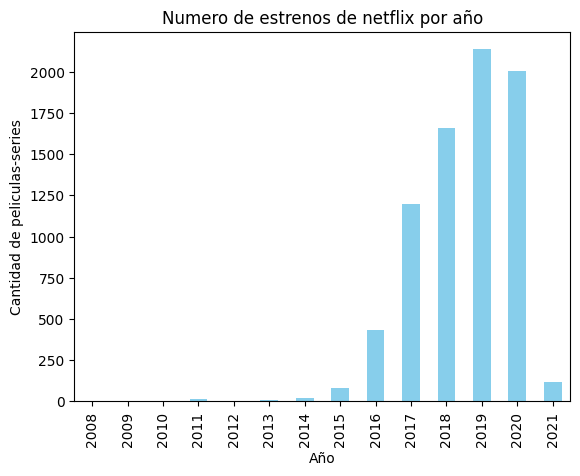

In [8]:
#Contar titulos por año
conteo_title=df["Year"].value_counts().sort_index()
conteo_title.head()

#------------VISUALIZACION--------------

#Grafico de barras
conteo_title.plot(kind="bar", color="skyblue")

#Titulo
plt.title("Numero de estrenos de netflix por año")

#Etiqueta en x
plt.xlabel("Año")

#Etiqueta en y
plt.ylabel("Cantidad de peliculas-series")

#Mostramos
plt.show()



## **Informe sobre estrenos de Netflix por año**

### Introducción
El análisis de la columna `Release_Date` del dataset de Netflix permite observar la evolución en la cantidad de estrenos (películas y series) a lo largo del tiempo. Para ello se extrajo el año de cada fecha y se contabilizó el número de títulos estrenados por año.

### Resultados
El gráfico de barras muestra una tendencia clara:

- **2014 – 2018**: Se observa un crecimiento sostenido en la cantidad de estrenos, reflejando la estrategia de expansión de Netflix en su catálogo original.
- **2019**: Se alcanza el **pico máximo**, con más de 2000 estrenos en un solo año.
- **2020 – 2021**: Se produce una caída abrupta en la cantidad de estrenos, reduciéndose casi a la mitad en comparación con 2019.

### Interpretación
La tendencia ascendente hasta 2019 refleja la consolidación de Netflix como líder en el mercado de streaming, con una fuerte inversión en contenido original.  
La caída posterior puede explicarse por factores externos, principalmente la **pandemia de COVID-19**, que interrumpió rodajes y retrasó estrenos a nivel global. Además, es posible que Netflix haya ajustado su estrategia hacia menos cantidad y mayor foco en calidad o producciones locales.

### Conclusión
El análisis evidencia cómo los estrenos de Netflix crecieron de manera acelerada hasta 2019, alcanzando un máximo histórico, seguido de una caída marcada en los años posteriores. Este comportamiento está fuertemente influenciado por el contexto mundial y las decisiones estratégicas de la plataforma.


-----
### **3. ¿Cuántas películas y series de televisión hay en el dataset? → gráfico de barras** 

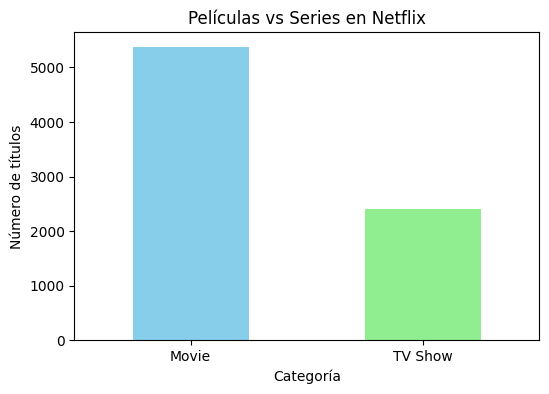

In [9]:
#Guardamos la cantidad de peliculas y series en una variable conteo_df
conteo_df=df["Category"].value_counts()

#Ajustamos las medidas (ancho, alto)
plt.figure(figsize=(6,4))

#Creamos graficos de barra skyblue para movie y lightgreen para tv show o series
conteo_df.plot(kind="bar", color=["skyblue","lightgreen"])

#Titulo
plt.title("Películas vs Series en Netflix")

#Etiqueta X
plt.xlabel("Categoría")

#Etiqueta Y
plt.ylabel("Número de títulos")

#Orientacion
plt.xticks(rotation=0)  #Controla la orientación de las etiquetas del eje X. Por defecto, Matplotlib puede rotar los nombres si son largos.rotation=0 → las etiquetas quedan horizontales.

#Mostramos
plt.show()



# **Informe: Películas vs Series en Netflix**

El análisis muestra que Netflix cuenta con una cantidad significativamente mayor de **películas** en su catálogo en comparación con las **series de televisión**.  
Esto puede interpretarse como una estrategia orientada a ofrecer un gran volumen de estrenos rápidos (películas), mientras que las series, aunque menos numerosas, requieren más tiempo de producción y representan apuestas de mayor calidad y continuidad.  

En conjunto, la plataforma equilibra cantidad y calidad: las películas aportan diversidad inmediata, y las series consolidan la relación con los usuarios a largo plazo.


------
### **4. Mostrar todas las películas estrenadas en el año 2020** 

In [10]:
# Usamos la función auxiliar creada anteriormente
peliculas_2020 = peliculas_por_año(df, 2020)

print("Películas estrenadas en 2020:")
print(peliculas_2020)


Películas estrenadas en 2020:
['21', '122', '3022', '#Alive', '#AnneFrank - Parallel Stories', '#cats_the_mewvie', '#FriendButMarried', '#FriendButMarried 2', 'Òlòtūré', '18 Presents', '1BR', '2 Alone in Paris', '28 Days', '3 Days to Kill', '365 Days', '37 Seconds', '40 Sticks', '4th Republic', '50 First Dates', '5Gang', '93 Days', "A Babysitter's Guide to Monster Hunting", 'A Bad Moms Christmas', 'A Bridge Too Far', 'A California Christmas', 'A Champion Heart', 'A Chaster Marriage', 'A Choo', 'A Christmas Catch', 'A Cinderella Story', 'A Clockwork Orange', 'A Fall from Grace', 'A Ghost Story', 'A Go! Go! Cory Carson Christmas', 'A Go! Go! Cory Carson Halloween', 'A Go! Go! Cory Carson Summer Camp', 'A Haunted House', 'A Kid from Coney Island', 'A Life of Speed: The Juan Manuel Fangio Story', 'A Love Song for Latasha', 'A New York Christmas Wedding', 'A Princess for Christmas', 'A Secret Love', 'A Shaun the Sheep Movie: Farmageddon', 'A Sun', 'A Thin Line Between Love & Hate', 'A Thous

**Interpretación:**  
La lista muestra todas las películas estrenadas en Netflix durante el año 2020.  
Este resultado permite analizar el impacto de la pandemia en la producción y estrenos de películas, ya que se observa una reducción respecto a años anteriores.


----
### **5. Mostrar solo los títulos de programas de TV emitidos únicamente en India.** 

In [11]:
# Filtramos programas con categoría TV Show y país India
programas_india = df[(df["Category"] == "TV Show") & (df["Country"] == "India")]

# Imprimimos en formato lista
print("Programas de TV emitidos en India:")
print(programas_india["Title"].tolist())

# Contamos cuántos fueron en total
total_india = programas_india["Title"].count()
print(f"Cantidad total de programas de TV de India: {total_india}")


Programas de TV emitidos en India:
['21 Sarfarosh: Saragarhi 1897', '7 (Seven)', 'Agent Raghav', 'Akbar\xa0Birbal', 'Anjaan: Rural Myths', 'Anjaan: Special Crimes Unit', 'Bad Boy Billionaires: India', 'Badalte Rishton Ki Dastaan', 'Bard of Blood', 'Betaal', 'Bh Se Bhade', 'Bhaag Beanie Bhaag', 'Bhaage Re Mann', 'Chhota Bheem', 'ChuChu TV Nursery Rhymes & Kids Songs (Hindi)', 'Classic Legends', 'College Romance', 'Cricket Fever: Mumbai Indians', 'Darr Sabko Lagta Hai', 'Delhi Crime', 'Devlok with Devdutt Pattanaik', 'Dharmakshetra', 'Engineering Girls', 'Fabulous Lives of Bollywood Wives', 'Fear Files... Har Mod Pe Darr', 'Gabru: Hip Hop Revolution', 'Gangs of Hassepur', 'GHOUL', 'Girls Hostel', 'Hasmukh', 'Inmates', 'Jamtara - Sabka Number Ayega', 'Jhansi Ki Rani', 'Khan: No. 1 Crime Hunter', 'Khelti Hai Zindagi Aankh Micholi', 'Khotey Sikkey', 'Ladies Up', 'Leila', 'Little Singham', 'Little Things', 'Maharakshak Devi', 'Maharakshak: Aryan', 'Mahi Way', 'Masaba Masaba', 'Midnight Misad

**Interpretación:**  
El resultado muestra todos los programas de TV de India disponibles en el catálogo de Netflix y su cantidad total.  
Esto refleja la estrategia de la plataforma de incluir producciones locales para captar audiencias regionales y diversificar su oferta.


En total se emitieron 71 programas en la india

----------
### **6. Top 10 directores con más títulos en Netflix.**  

Director
Desconocido               2388
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Martin Scorsese             12
Youssef Chahine             12
Steven Spielberg            10
David Dhawan                 9
Name: Title, dtype: int64


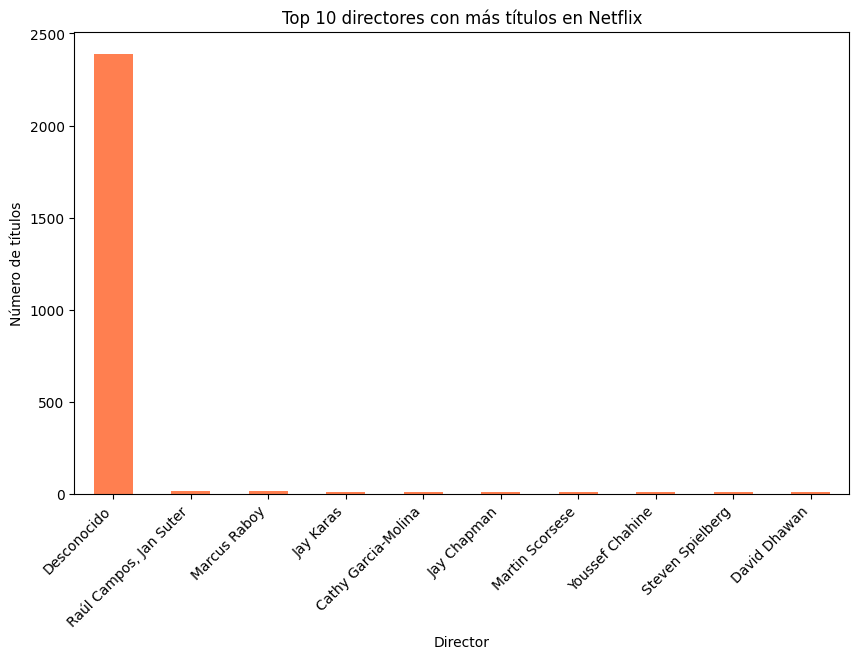

In [12]:
# Agrupar por director y contar títulos
top_directores = (
    df.groupby("Director")["Title"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)
print(top_directores)

#----------------VISUALIZACION------------

# Gráfico de barras
plt.figure(figsize=(10,6))
top_directores.plot(kind="bar", color="coral")
plt.title("Top 10 directores con más títulos en Netflix")
plt.xlabel("Director")
plt.ylabel("Número de títulos")
plt.xticks(rotation=45, ha="right")
plt.show()


**Interpretación:**  
El resultado muestra los directores con mayor presencia en el catálogo de Netflix.  
Esto refleja tanto la popularidad de sus producciones como la estrategia de la plataforma de incluir obras de directores prolíficos para enriquecer su oferta.  
indicando que gran parte de las producciones no tienen director registrado


----
### **7. Audiencias definidas por Netflix:**
  
   - 7.1) ¿Cuántas películas tienen calificación **TV-14** en Canadá?  
   - 7.2) ¿Cuántos programas de TV tienen calificación **R** después de 2018?  
   
-----

  
   **- 7.1) ¿Cuántas películas tienen calificación **TV-14** en Canadá?**  

In [13]:
# Filtramos películas con rating TV-14 y país Canadá
peliculas_tv14_canada = df[
    (df["Category"] == "Movie") &
    (df["Rating"] == "TV-14") &
    (df["Country"].str.contains("Canada", na=False))
]

# Mostramos la cantidad
print("Cantidad de películas TV-14 en Canadá:", len(peliculas_tv14_canada))


Cantidad de películas TV-14 en Canadá: 26


**Interpretación:**  
El resultado indica cuántas películas con clasificación **TV‑14** se produjeron en Canadá y están disponibles en el catálogo de Netflix.  
Este tipo de análisis permite observar la presencia de producciones canadienses en un rango de clasificación pensado para adolescentes y público joven.


**- 7.2) ¿Cuántos programas de TV tienen calificación **R** después de 2018?** 

In [14]:
# Filtramos programas de TV con rating R posteriores a 2018
tv_r_post2018 = df[
    (df["Category"] == "TV Show") &
    (df["Rating"] == "R") &
    (df["Year"] > 2018)
]

# Mostramos la cantidad
print("Cantidad de programas de TV con rating R después de 2018:", len(tv_r_post2018))


Cantidad de programas de TV con rating R después de 2018: 1


**Interpretación:**  
El resultado indica cuántos programas de TV con clasificación **R** (contenido restringido para adultos) se estrenaron en Netflix a partir de 2019.  
Este análisis permite observar la presencia de producciones más maduras en años recientes, lo que refleja la diversificación del catálogo hacia distintos públicos.


------
### **Distribucion de titulos por pais en netflix**


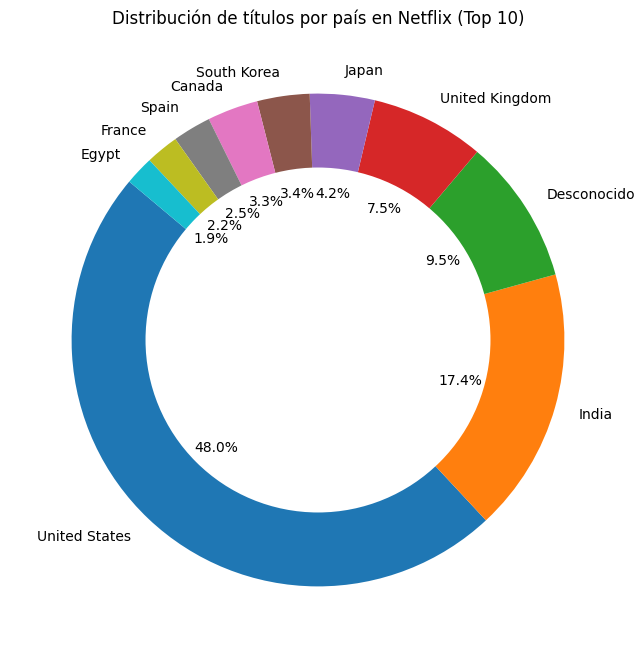

In [15]:
#Guardamos el conteo de valores en la variable
conteo_paises = df["Country"].value_counts().head(10)  # Top 10 países

#Ingresamos las medidas 
plt.figure(figsize=(8,8))

#Crea el grafico de torta con la cantidad de titulos por paises,las etiquetas son los nombres de los paises,muestra el porcentaje con un decimal y rota el grafico para que empieze de un angulo mas estetico
plt.pie(conteo_paises, labels=conteo_paises.index, autopct="%1.1f%%", startangle=140)

# Para convertirlo en dona, agregamos un círculo blanco en el centro
centre_circle = plt.Circle((0,0),0.70,fc="white")

#guardamos la figura actual en la variable
fig = plt.gcf()

#Agregamos el circulo blanxo
fig.gca().add_artist(centre_circle)

#Titulo
plt.title("Distribución de títulos por país en Netflix (Top 10)")

#Mostramos
plt.show()


# Informe: Distribución de títulos por país

El gráfico de dona muestra la proporción de títulos de Netflix según el país de origen.  
Se observa que Estados Unidos concentra la mayor parte del catálogo, seguido por India y producciones sin paises registrados.  
Otros países como Reino Unido, Japon y Corea del Sur también tienen presencia significativa, mientras que el resto se distribuye en proporciones menores.


### **9. ¿Cuál es la duración máxima de una película/serie en Netflix?**  

In [16]:
# Convertimos la columna Duration en valores numéricos (quitando 'min' y 'Season(s)')
# Para películas (minutos)
df_movies = df[df["Category"] == "Movie"].copy()
df_movies["Duration_num"] = df_movies["Duration"].str.replace(" min","").astype(int)

# Para series (temporadas)
df_series = df[df["Category"] == "TV Show"].copy()
df_series["Duration_num"] = df_series["Duration"].str.replace(" Season","").str.replace("s","").astype(int)

# Duración máxima
max_movie = df_movies["Duration_num"].max()
max_series = df_series["Duration_num"].max()

print(f"Duración máxima de una película: {max_movie} minutos")
print(f"Duración máxima de una serie: {max_series} temporadas")


Duración máxima de una película: 312 minutos
Duración máxima de una serie: 16 temporadas


**Interpretación:**  
El resultado muestra la película con mayor duración en minutos y la serie con más temporadas dentro del catálogo de Netflix.  
Esto permite identificar los títulos más extensos en cada categoría, reflejando tanto producciones cinematográficas largas como series de gran continuidad.
